In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import os
from aeon.visualisation import plot_critical_difference

INCLUDE_BASELINE = False

In [2]:
results_uni_path = "eval/metrics/uni"
results_uni_path_baseline = "eval/metrics/uni_baseline"

metrics = ["VUS-ROC", "VUS-PR", 'Standard-F1', 'PA-F1', 'Event-based-F1', 'R-based-F1', 'Affiliation-F']

models_results = os.listdir(results_uni_path)

df_metrics = {metric: pd.DataFrame() for metric in metrics}
for model in models_results:
    model_path = os.path.join(results_uni_path, model)
    res = pd.read_csv(model_path)
    for metric in metrics:
        df_metrics[metric][model.split(".")[0]] = res[metric]

if INCLUDE_BASELINE:
    models_results_baseline = os.listdir(results_uni_path_baseline)
    for model in models_results_baseline:
        model_path = os.path.join(results_uni_path_baseline, model)
        res = pd.read_csv(model_path)
        for metric in metrics:
            df_metrics[metric][model.split(".")[0]] = res[metric]

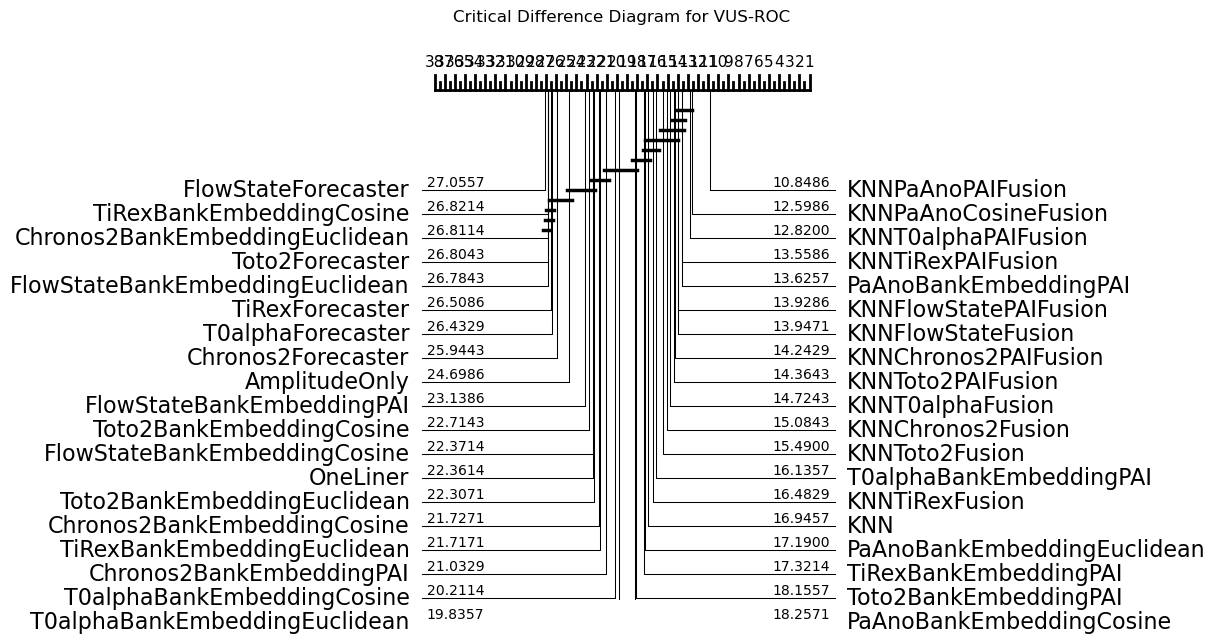

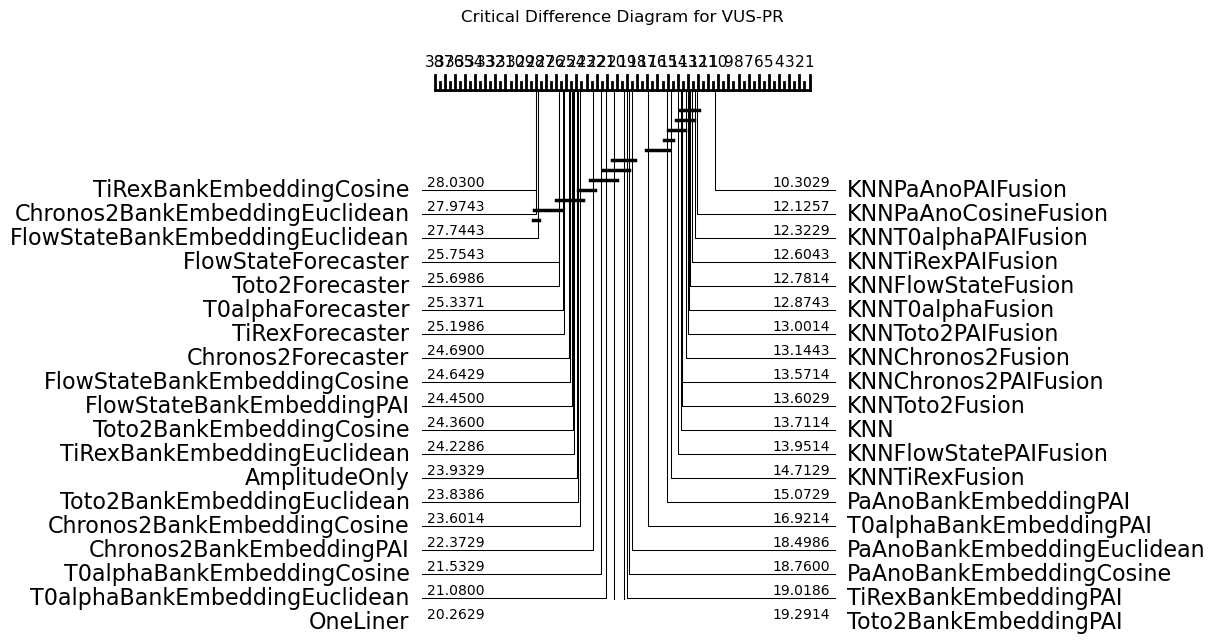

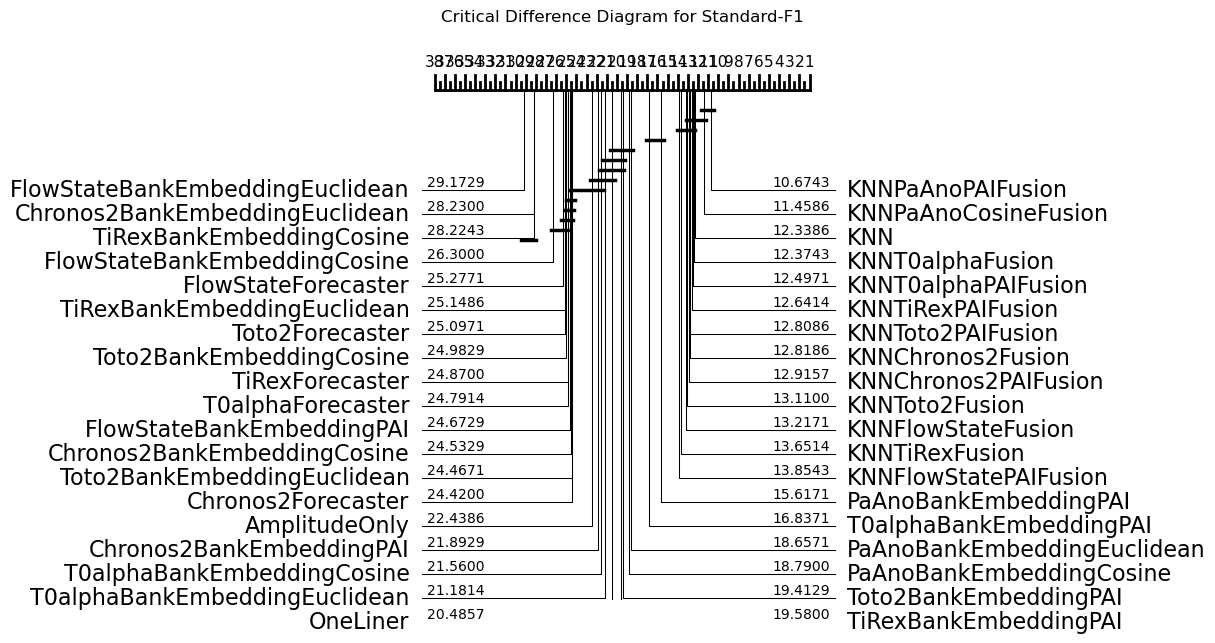

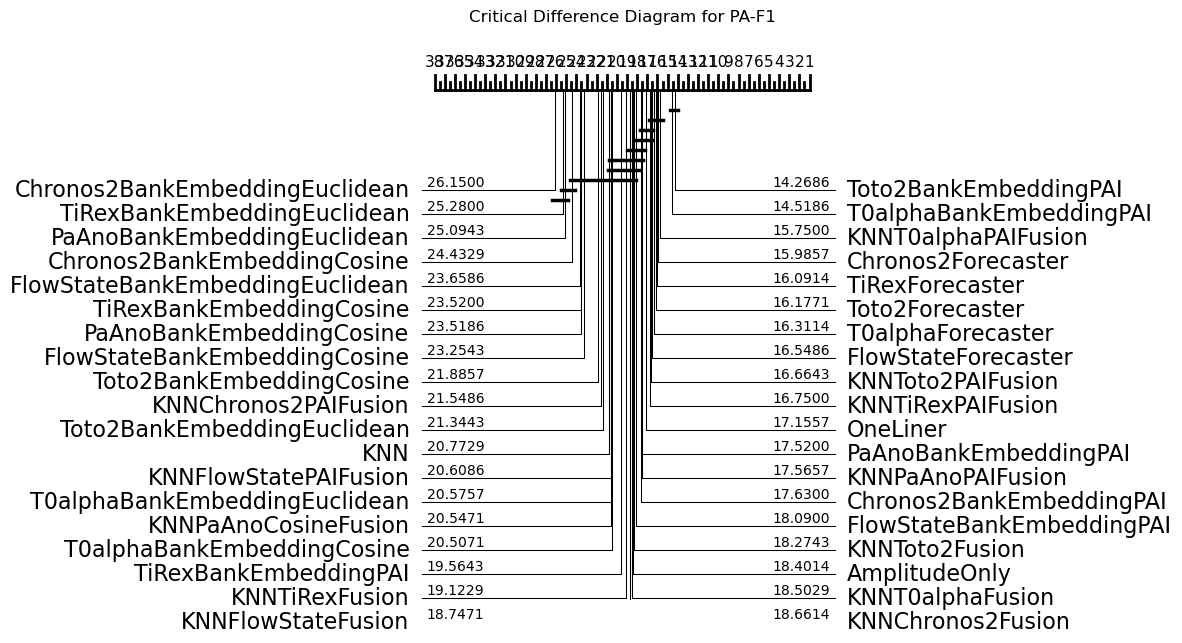

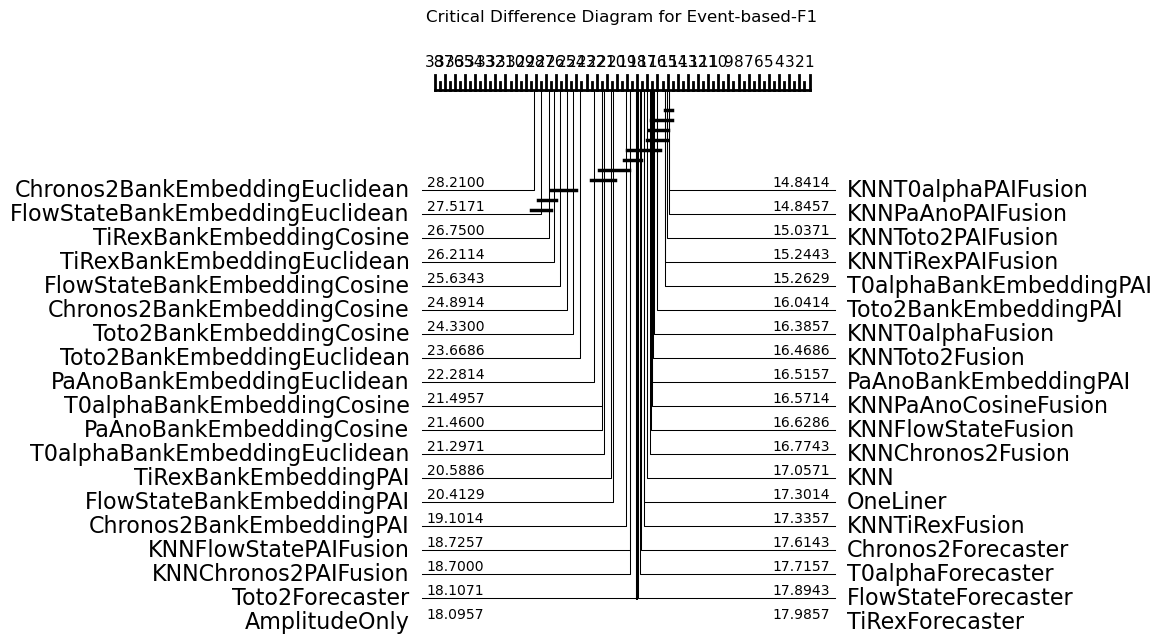

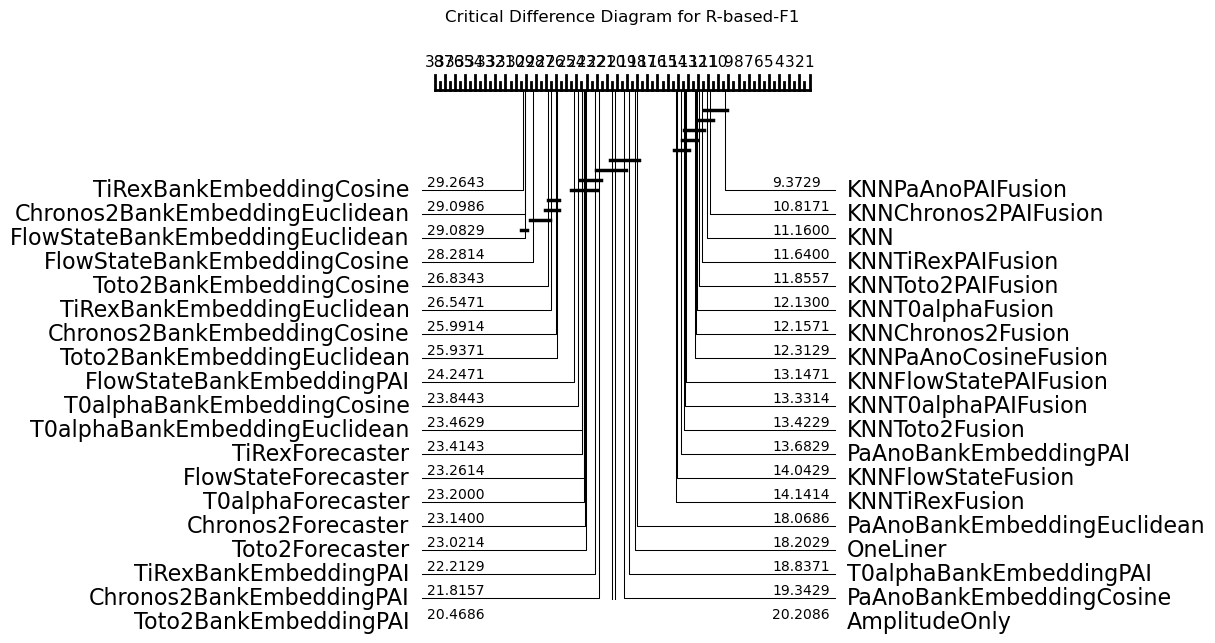

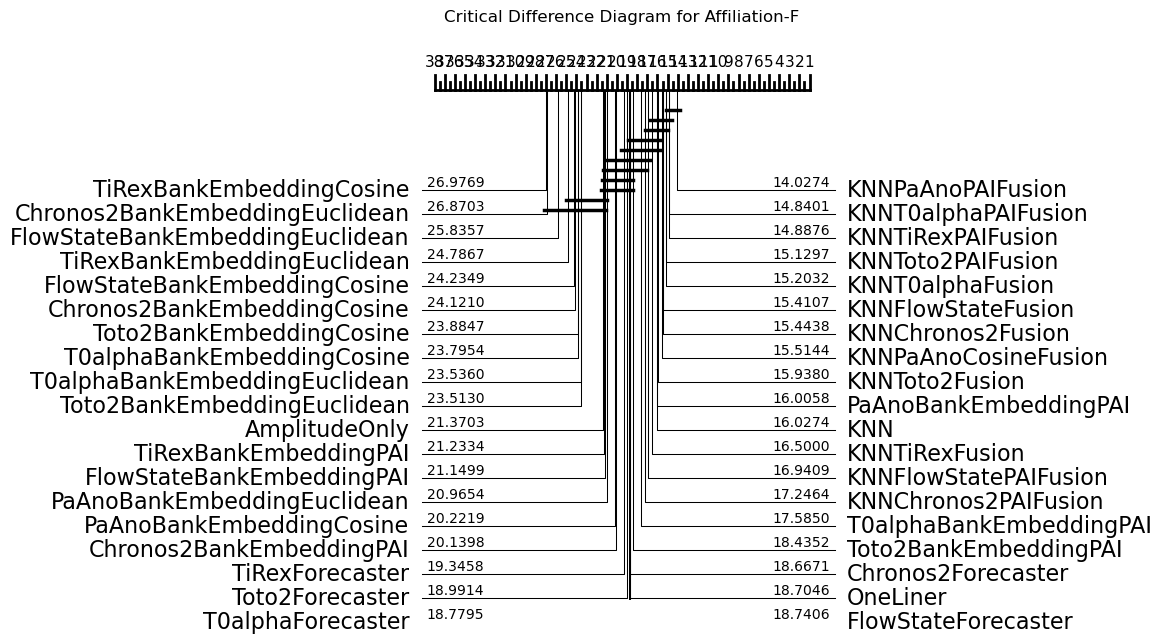

In [3]:
for i, metric in enumerate(metrics):
    df = df_metrics[metric]
    df = df.dropna(axis=1, how="all")
    df = df.dropna(axis=0, how="any")
    plot_critical_difference(df.values, df.columns)
    plt.title(f"Critical Difference Diagram for {metric}")